# Zone Analysis

**Purpose:** load and classify mine zones (material type + load/unload type), build plottable polygons from the raw vertex list, and visualize them. Pure zone-geometry exploration — no truck data.

In [1]:
import sys
sys.path.append("../..")

from gps_lib import io_utils, classify, zones, plotting

In [2]:
zone_list_df = io_utils.load_zone_list()
zone_list_df = classify.classify_zones(zone_list_df)
filtered_df = zone_list_df[zone_list_df["zone_material_type"] != "other"].copy()
filtered_df.shape

(12, 15)

In [ ]:
zone_list_df.head()

,Unnamed: 0,id,label,address,color,type,bounds_se_lat,bounds_se_lng,bounds_nw_lat,bounds_nw_lng,radius,center_lat,center_lng,zone_material_type,zone_load_type
0,0,25334,Reject овоолго,Address,27A9E3,polygon,43.675834,105.544349,43.693166,105.516257,NaN,NaN,NaN,reject,unload
1,1,25336,Sp3,Address,FF9800,polygon,43.660626,105.534864,43.664390,105.531162,NaN,NaN,NaN,other,unload
2,2,25337,Станц хашаа,Address,03A9F4,polygon,43.670562,105.540895,43.671485,105.538031,NaN,NaN,NaN,other,unload
3,3,25338,S20 Овоолго,Address,3F51B5,polygon,43.670037,105.546279,43.673467,105.541331,NaN,NaN,NaN,other,unload
4,4,25357,Кемп,Address,81C784,polygon,43.687233,105.556652,43.688686,105.554670,NaN,NaN,NaN,other,unload
5,5,25384,Reject ачилтын бүс,Address,27A9E3,polygon,43.665743,105.535617,43.667577,105.533019,NaN,NaN,NaN,reject,load
6,6,25385,Middling ачилтын бүс,Address,27A9E3,polygon,43.664387,105.539222,43.666122,105.536143,NaN,NaN,NaN,middling,load
7,7,25401,Баяжуулах үйлдвэрийн нүүрс,Address,27A9E3,polygon,43.667546,105.535612,43.669121,105.533381,NaN,NaN,NaN,other,unload
8,8,25412,Уурхайчин хороолол,Address,27A9E3,polygon,43.711006,105.578210,43.714555,105.565378,NaN,NaN,NaN,other,unload
9,9,25413,Цогтцэций сум,Address,27A9E3,circle,43.708845,105.597990,43.743558,105.549960,1930.0,43.726204,105.573978,other,unload


In [3]:
print("reject:", filtered_df.loc[filtered_df.zone_material_type == "reject", "label"].tolist())
print("bn:", filtered_df.loc[filtered_df.zone_material_type == "bn", "label"].tolist())
print("middling:", filtered_df.loc[filtered_df.zone_material_type == "middling", "label"].tolist())

reject: ['Reject овоолго', 'Reject ачилтын бүс']
bn: ['Баруун наран ачилтын бүс  /Зүүн/', 'Баруун наран овоолго ', 'Баруун наран ачилтын бүс /Баруун/']
middling: ['Middling ачилтын бүс', 'SP4', 'Sp5', 'SP7', 'Hard sp5', 'SP7 шинэ үүссэн', 'SP7 hard']


In [4]:
zone_detail_all_df = io_utils.load_zone_detail()
fixed_df = zones.build_ordered_zone_polygons(zone_detail_all_df)
fixed_df.head()

,zone_id,lat,lng,is_close_vertex
0,25334,43.677184,105.521321,False
1,25334,43.675834,105.528413,False
2,25334,43.676113,105.532157,False
3,25334,43.676454,105.533391,False
4,25334,43.677060,105.534239,False


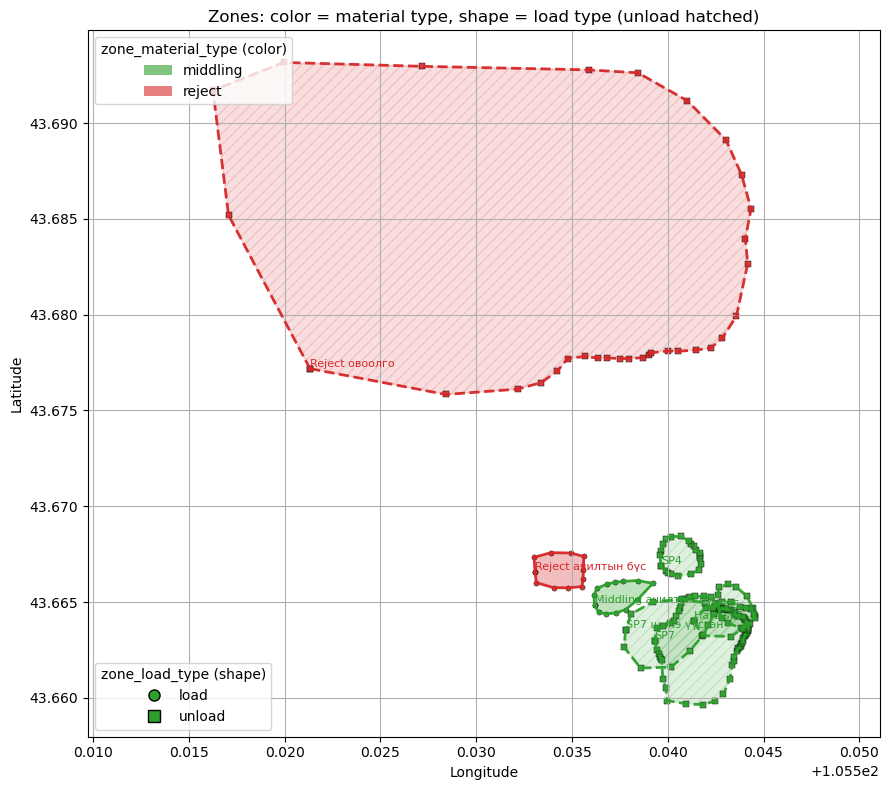

<Axes: title={'center': 'Zones: color = material type, shape = load type (unload hatched)'}, xlabel='Longitude', ylabel='Latitude'>

In [5]:
plotting.plot_zones(fixed_df, filtered_df, material_types=["reject", "middling"], load_types=["load", "unload"])

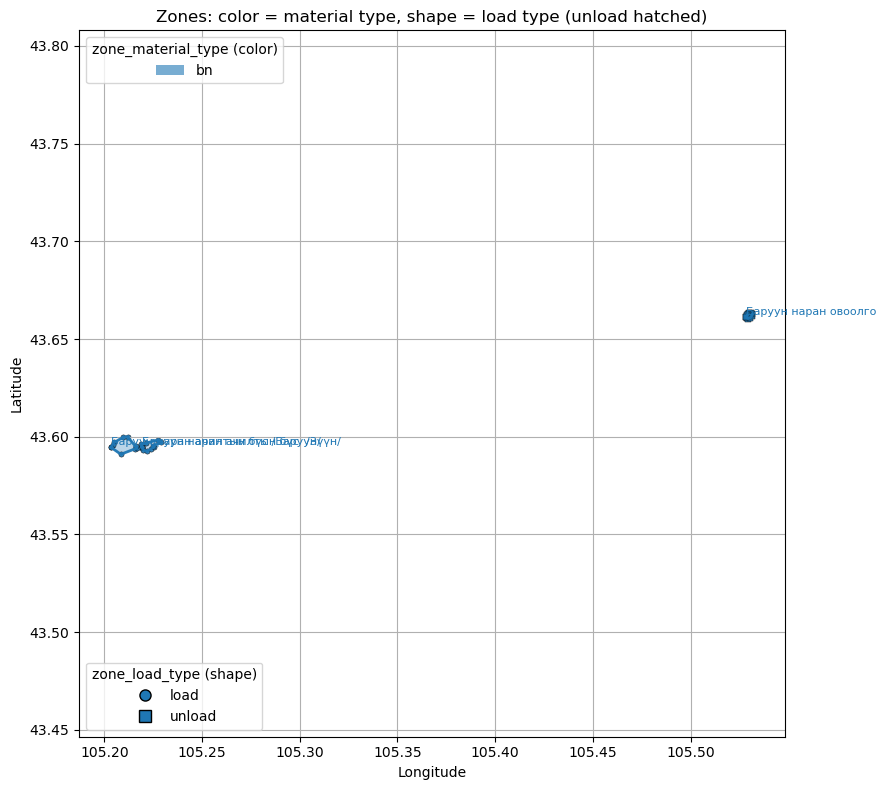

<Axes: title={'center': 'Zones: color = material type, shape = load type (unload hatched)'}, xlabel='Longitude', ylabel='Latitude'>

In [6]:
plotting.plot_zones(fixed_df, filtered_df, material_types=["bn"], load_types=["load", "unload"])

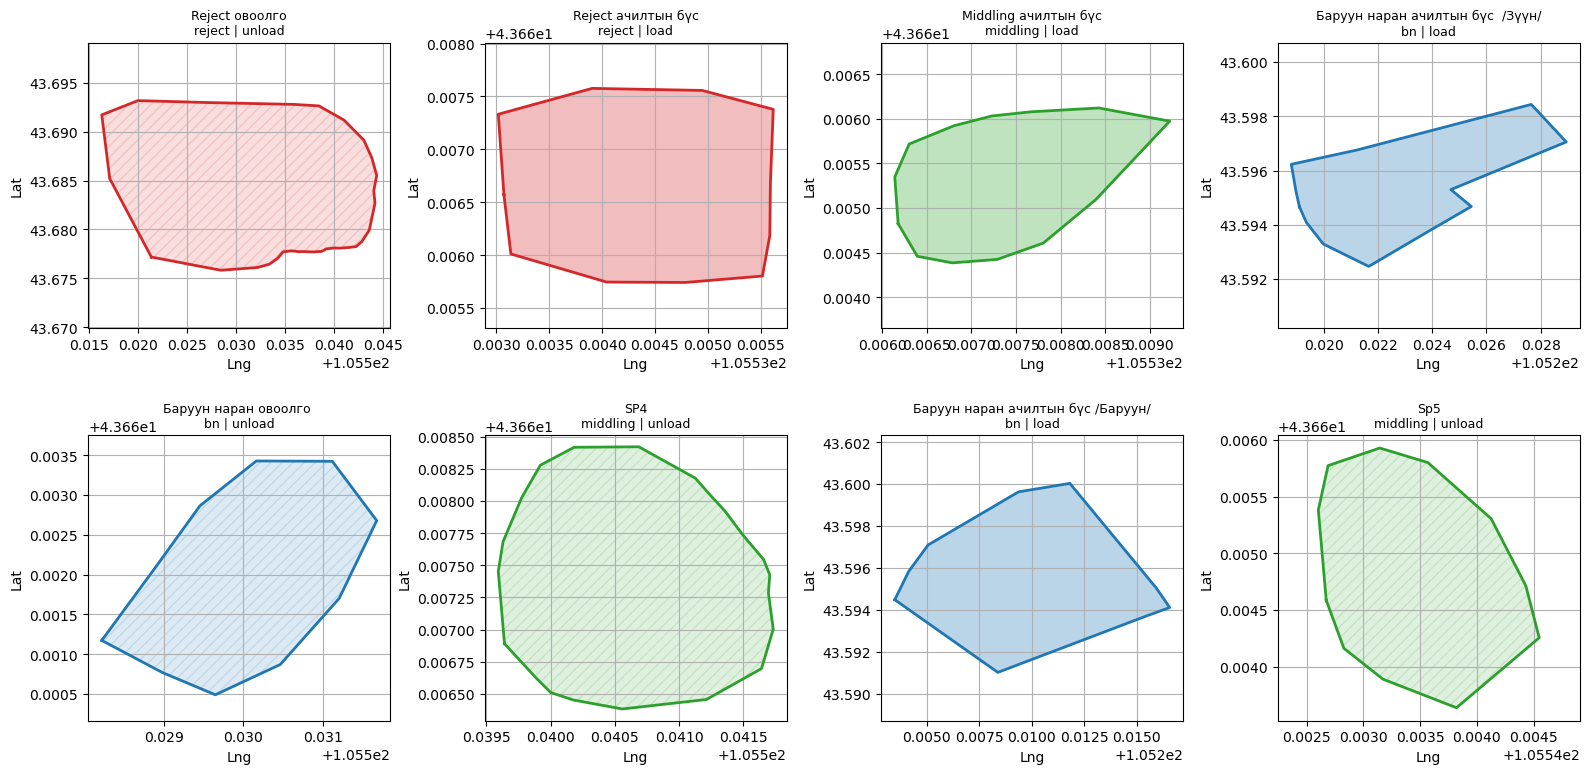

(<Figure size 1600x800 with 8 Axes>,
 array([[<Axes: title={'center': 'Reject овоолго\nreject | unload'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'Reject ачилтын бүс\nreject | load'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'Middling ачилтын бүс\nmiddling | load'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'Баруун наран ачилтын бүс  /Зүүн/\nbn | load'}, xlabel='Lng', ylabel='Lat'>],
        [<Axes: title={'center': 'Баруун наран овоолго \nbn | unload'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'SP4\nmiddling | unload'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'Баруун наран ачилтын бүс /Баруун/\nbn | load'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'Sp5\nmiddling | unload'}, xlabel='Lng', ylabel='Lat'>]],
       dtype=object))

In [7]:
zone_ids = fixed_df["zone_id"].dropna().unique().tolist()[:8]
plotting.plot_zones_grid(fixed_df, filtered_df, zone_ids=zone_ids, ncols=4, figsize_per_plot=(4, 4))